In [84]:
import torch
from torch import nn
from matplotlib import pyplot as plt
import torch.nn.functional as F
from d2l import torch as d2l
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import os

In [85]:
d2l.DATA_HUB['ml-100k'] = (
    'https://files.grouplens.org/datasets/movielens/ml-100k.zip',
    'cd4dcac4241c8a4ad7badc7ca635da8a69dddb83')

#@save
def read_data_ml100k():
    data_dir = d2l.download_extract('ml-100k')
    names = ['user_id', 'item_id', 'rating', 'timestamp']
    data = pd.read_csv(os.path.join(data_dir, 'u.data'), sep='\t',
                       names=names, engine='python')
    num_users = data.user_id.unique().shape[0]
    num_items = data.item_id.unique().shape[0]
    return data, num_users, num_items

In [86]:
def split_data_ml100k(data, num_users, num_items, split_mode='random', test_ratios=0.1):
    if (split_mode == 'seq_aware'):
        train_items, test_items, train_list = {}, {}, []
        for line in data.itertuples():
            u, i, rating, time = line[0], line[1], line[2], line[3]
            train_items.setdefault(u, []).append((u, i, rating, time))
            if u not in test_items or test_items[u][-1] < time:
                test_items[u] = (i, rating, time)

        for u in range(1, num_users + 1):
            train_list.extend(sorted(train_items[u], key=lambda k: k[3]))
        test_data = [(key, *values) for key, values in test_items.items()]
        train_data = [item for item in train_items.items() if item not in test_data]
        train_data = pd.DataFrame(train_data)
        test_data = pd.DataFrame(test_data)
    else:
        mask = [True if x == 1 else False for x in np.random.uniform(0, 1, (len(data))) < 1 - test_ratios]
        neg_mask = [not i for i in mask]
        train_data, test_data = data[mask], data[neg_mask]

    return train_data, test_data

In [87]:
def load_data_ml100k(data, num_users, num_items, feedback='explicit'):
    users, items, scores = [], [], []
    inter = np.zeros((num_items, num_users)) if feedback == 'explicit' else {}
    for line in data.itertuples():
        user_index, item_index = int(line[1] - 1), int(line[2] - 1)
        score = int(line[3]) if feedback == 'explicit' else 1
        users.append(user_index)
        items.append(item_index)
        scores.append(score)
        if feedback != 'explicit':
            inter.setdefault(user_index, []).append(item_index)
        else:
            inter[item_index][user_index] = score

    return users, items, scores, inter

In [88]:
def split_and_load_ml100k(split_mode='seq-aware', feedback='explicit',
                          test_ratio=0.1, batch_size=256):
    data, num_users, num_items = read_data_ml100k()
    train_data, test_data = split_data_ml100k(
        data, num_users, num_items, split_mode, test_ratio)
    train_u, train_i, train_r, _ = load_data_ml100k(
        train_data, num_users, num_items, feedback)
    test_u, test_i, test_r, _ = load_data_ml100k(
        test_data, num_users, num_items, feedback)

    train_u = torch.tensor(train_u, dtype=torch.long)
    train_i = torch.tensor(train_i, dtype=torch.long)
    train_r = torch.tensor(train_r, dtype=torch.float32)

    test_u = torch.tensor(test_u, dtype=torch.long)
    test_i = torch.tensor(test_i, dtype=torch.long)
    test_r = torch.tensor(test_r, dtype=torch.float32)

    train_set = TensorDataset(
       train_u, train_i, train_r 
    )
    
    test_set = TensorDataset(
       test_u, test_i, test_r 
    )

    train_iter = DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=False)
    test_iter = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    
    return num_users, num_items, train_iter, test_iter

In [ ]:
def train_recsys_rating(net, train_iter, test_iter, epochs, trainer, device, loss, evaluator=None, **kwargs):
    net = net.to(device)
    timer = d2l.Timer()
    fig, ax = plt.subplots(1, 1)
    loss_curv = []
    num_epochs = [i for i in range(epochs)]

    for epoch in range(epochs):
        metric = d2l.Accumulator(3)
        net.train()
        loss_epoch = 0

        for i, values in enumerate(train_iter):
            timer.start()
            trainer.zero_grad()
            values = [v.to(device) for v in values]

            train_feats = values[:-1]
            train_label = values[-1]

            preds = net(*train_feats)

            l = loss(preds, train_label) 

            l.backward()
            trainer.step()

            batch_size = train_label.shape[0]
            metric.add(l.item() * batch_size, batch_size, train_label.numel())
            timer.stop() 
            loss_epoch += l.item() * batch_size

        if len(kwargs) > 0:              
            test_rmse = evaluator(net, test_iter, kwargs['inter_mat'], device)
        else:
            test_rmse = evaluator(net, test_iter, device) 

        train_l = metric[0] / metric[1]
        loss_curv.append(loss_epoch / metric[1])

    ax.plot(num_epochs, loss_curv, color='r')
    ax.set_xlabel('epochs')
    ax.set_ylabel('loss')
    fig.set_edgecolor('red')
    fig.show()

    print(f'train_loss: {train_l:.3f}\n')
    print(f'test_rmse: {test_rmse:.3f}\n')
    print(f'{metric[2] * epochs / timer.sum():.1f} example / sec\n')


In [90]:
class AutoRec(nn.Module):
    def __init__(self, num_user, latent_dim, **kwargs):
        super(AutoRec, self).__init__(**kwargs)
        self.V = nn.Linear(num_user, latent_dim, bias=True)
        self.W = nn.Linear(latent_dim, num_user, bias=True)
        self.activate = nn.Sigmoid()
        self.dropout = nn.Dropout(0.05)

    def forward(self, X):
        tmpY = self.dropout(self.activate(self.V(X)))
        Y = self.W(tmpY)

        return Y

In [91]:
def evaluator(net, test_iter, test_label, device):
    net.eval()
    scores = []

    with torch.no_grad():    
        for values in test_iter:
            feat = values[0].to(device)
            scores.append(net(feat).cpu().numpy())

    recons = np.concatenate(scores, axis=0)    

    rmse = np.sqrt(np.sum(np.square(np.sign(test_label) * recons - test_label)) / np.sum(np.sign(test_label))) 

    return float(rmse)

train_loss: 0.042

test_rmse: 0.926

172459377.0 example / sec



C:\Users\a9364\AppData\Local\Temp\ipykernel_14748\478649780.py:45: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


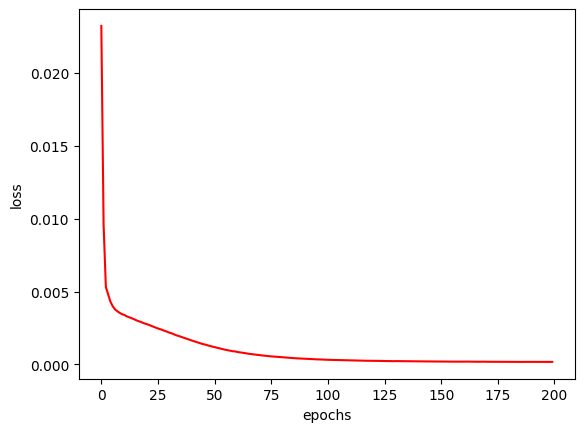

In [92]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

df, num_users, num_items = read_data_ml100k()
train_data, test_data = split_data_ml100k(df, num_users, num_items)
_, _, _, train_inter_mat = load_data_ml100k(train_data, num_users,
                                                num_items)
_, _, _, test_inter_mat = load_data_ml100k(test_data, num_users,
                                               num_items)

train_mat = torch.tensor(train_inter_mat, dtype=torch.float32).to(device)
test_mat = torch.tensor(test_inter_mat, dtype=torch.float32).to(device)

train_dataset = TensorDataset(train_mat, train_mat)
test_dataset = TensorDataset(test_mat)

batch_size = 256

train_iter = DataLoader(train_dataset, batch_size, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size, shuffle=False)

net = AutoRec(num_user=num_users, latent_dim=500)
lr = 2e-3
weight_decay = 1e-5
num_epochs = 200
def masked_mse_loss(pred, label):
    mask = (label > 0).to(pred.dtype)
    return F.mse_loss(pred * mask, label * mask, reduction="sum") / mask.sum().clamp(min=1)

loss = masked_mse_loss

optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
train_recsys_rating(net, train_iter, test_iter, num_epochs, optimizer, device, loss, evaluator, inter_mat=test_inter_mat)